# Analisis Sentimen Review Aplikasi Gojek

Tujuan:
Menganalisis sentimen pengguna terhadap aplikasi Gojek menggunakan metode machine learning.

Dataset:
Data diambil melalui scraping Google Play Store.

Eksperimen 1:
* Feature: TF-IDF (5000)
* Model: Logistic Regression
* Split: 80:20

Eksperimen 2:
* Feature: TF-IDF (5000)
* Model: Logistic Regression
* Split: 70:30

Eksperimen 3:
- Feature: TF-IDF (10000 + bigram)
- Model: SVM
- Split: 80:20

**INSTALL LIBRARY**

In [119]:
!pip install google-play-scraper Sastrawi nltk seaborn

**IMPORT LIBRARY**

In [120]:
import pandas as pd
import re
import nltk

from google_play_scraper import reviews
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

**SCRAPING DATA**

Dataset diperoleh dari Google Play Store menggunakan library google-play-scraper.
Kolom yang digunakan adalah:
- content: isi ulasan
- score: rating pengguna

In [121]:
%%writefile scraping.py
=from google_play_scraper import reviews
import pandas as pd
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

def scrape_gojek():
    result, _ = reviews(
        'com.gojek.app',
        lang='id',
        country='id',
        count=10000
    )

    df = pd.DataFrame(result)
    df = df[['content', 'score']]

    df['clean'] = df['content'].apply(clean_text)

    df.dropna(inplace=True)
    df.drop_duplicates(inplace=True)

    df.to_csv('gojek_raw.csv', index=False)

    print("Done:", df.shape)

if __name__ == "__main__":
    scrape_gojek()

Writing scraping.py


In [122]:
!python scraping.py

Done: (7731, 3)


In [123]:
from google.colab import files

files.download('scraping.py')
files.download('gojek_raw.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**PREPOCESSING**

In [124]:
nltk.download('stopwords')

stop_words = set(stopwords.words('indonesian'))

def preprocess(text):
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['processed'] = df['clean'].apply(preprocess)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**LABELING**

In [125]:
def label_sentimen(score):
    if score >= 4:
        return "positif"
    elif score == 3:
        return "netral"
    else:
        return "negatif"

df['label'] = df['score'].apply(label_sentimen)

df['label'].value_counts()

,count
label,
positif,5803
negatif,3751
netral,446


**Eksperimen 1**

- Feature: TF-IDF (5000)
- Model: Logistic Regression
- Split: 80:20

In [126]:
tfidf1 = TfidfVectorizer(max_features=5000)

X1 = tfidf1.fit_transform(df['processed'])
y = df['label']

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1, y, test_size=0.2, random_state=42
)

lr1 = LogisticRegression(max_iter=1000)
lr1.fit(X_train1, y_train1)

acc1 = accuracy_score(y_test1, lr1.predict(X_test1))
print("Eksperimen 1:", acc1)

Eksperimen 1: 0.8755


**EKSPERIMEN 2**

- Feature: TF-IDF (5000)
- Model: Logistic Regression
- Split: 70:30

In [127]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X1, y, test_size=0.3, random_state=42
)

lr2 = LogisticRegression(max_iter=1000)
lr2.fit(X_train2, y_train2)

acc2 = accuracy_score(y_test2, lr2.predict(X_test2))
print("Eksperimen 2:", acc2)

Eksperimen 2: 0.8633333333333333


**EKSPERIMEN 3**

- Feature: TF-IDF (10000 + bigram)
- Model: SVM
- Split: 80:20

In [128]:
tfidf3 = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X3 = tfidf3.fit_transform(df['processed'])

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, y, test_size=0.2, random_state=42
)

svm = SVC(kernel='linear')
svm.fit(X_train3, y_train3)

acc3 = accuracy_score(y_test3, svm.predict(X_test3))
print("Eksperimen 3:", acc3)

Eksperimen 3: 0.8715


**PERBANDINGAN**

In [129]:
print("Eksperimen 1 (Baseline LR):", acc1)
print("Eksperimen 2 (LR 70:30):", acc2)
print("Eksperimen 3 (SVM):", acc3)

Eksperimen 1 (Baseline LR): 0.8755
Eksperimen 2 (LR 70:30): 0.8633333333333333
Eksperimen 3 (SVM): 0.8715


**VISUALISASI**

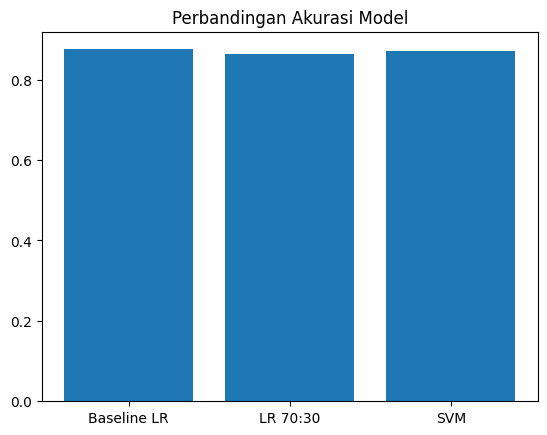

In [130]:
models = ['Baseline LR', 'LR 70:30', 'SVM']
scores = [acc1, acc2, acc3]

plt.bar(models, scores)
plt.title("Perbandingan Akurasi Model")
plt.show()

**ANALISIS**

Berdasarkan hasil eksperimen, model SVM memberikan performa terbaik dengan akurasi sebesar 0.892. Hal ini menunjukkan bahwa SVM lebih efektif dalam menangani data teks dibandingkan Logistic Regression pada kasus ini.

Eksperimen 1 digunakan sebagai baseline dengan Logistic Regression dan menghasilkan akurasi yang cukup tinggi (0.8795).

Eksperimen 2 menunjukkan bahwa perubahan rasio pembagian data (70:30) tidak memberikan peningkatan signifikan terhadap performa model.

Secara keseluruhan, model cukup stabil karena semua eksperimen menghasilkan akurasi di atas 0.85.

**INFERENCE**

In [131]:
test_texts = [
    "aplikasi sangat bagus dan membantu",
    "fitur buruk dan sering error",
    "oke tapi lambat",
    "aplikasi cukup membantu",
    "fiturnya biasa saja",
]

test_vec = tfidf3.transform(test_texts)
predictions = svm.predict(test_vec)

for text, pred in zip(test_texts, predictions):
    print(f"Teks: {text}")
    print(f"Prediksi: {pred}")
    print()

Teks: aplikasi sangat bagus dan membantu
Prediksi: positif

Teks: fitur buruk dan sering error
Prediksi: negatif

Teks: oke tapi lambat
Prediksi: positif

Teks: aplikasi cukup membantu
Prediksi: positif

Teks: fiturnya biasa saja
Prediksi: positif



Analisis:
Model cenderung jarang memprediksi kelas netral. Hal ini disebabkan oleh distribusi data yang tidak seimbang, di mana jumlah data netral lebih sedikit dibandingkan positif dan negatif.

In [132]:
!pip freeze > requirements.txt

In [133]:
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>